# Programming Assignment 3: Counterfactual Regret Minimization
## CPSC 631: Intelligent Agents

**Due Date:** Friday, Oct. 31, 11:59pm

**Student Name: Nicholas Garde**  
**Student ID: 227006946**

---

## Overview

In this assignment, you will implement **Counterfactual Regret Minimization (CFR)** to solve **Kuhn Poker**, a simple 3-card poker game. CFR is a powerful algorithm for finding approximate Nash equilibria in imperfect-information games.

### Learning Objectives
- Understand extensive-form game representation
- Implement counterfactual value computation
- Apply regret matching for strategy updates
- Empirically verify convergence to Nash equilibrium

### Kuhn Poker Rules
- **Players:** 2 (P0 and P1)
- **Deck:** 3 cards {Jack=0, Queen=1, King=2}
- **Ante:** Each player puts 1 chip in the pot
- **Deal:** Each player receives one card (uniformly at random)
- **Betting:**
  1. P0 acts first: **Pass** or **Bet** (add 1 chip)
  2. If P0 passes:
     - P1 can **Pass** (showdown) or **Bet** (add 1 chip)
     - If P1 bets, P0 can **Call** (add 1 chip, showdown) or **Fold** (P1 wins)
  3. If P0 bets:
     - P1 can **Call** (add 1 chip, showdown) or **Fold** (P0 wins)
- **Showdown:** Higher card wins the pot

### Information Sets
Each player has 6 information sets:
- **P0:** `0`, `1`, `2` (card held, initial decision), `0pb`, `1pb`, `2pb` (card held, after pass-bet)
- **P1:** `0p`, `1p`, `2p` (card held, after opponent pass), `0b`, `1b`, `2b` (card held, after opponent bet)

---

## Submission Instructions
1. Complete all `TODO` cells below
2. Run all cells to ensure your code executes without errors
3. Answer the reflection questions in the final section
4. Submit this notebook (`.ipynb`) via the course portal

**Academic Integrity:** This is an individual assignment. You may discuss high-level concepts with classmates but must write your own code.

---

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import Dict, List, Tuple
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

print("Setup complete!")

Setup complete!


---
## Task 1: Game Representation (25 points)

Define the game tree structure for Kuhn Poker.

### Key Concepts
- **History:** A sequence of actions (e.g., "pb" = pass, then bet)
- **Information Set:** The combination of a player's private card and the public history
- **Actions:** At each decision point, available actions (Pass/Bet or Call/Fold)

### Your Task
Implement the `KuhnPoker` class with:
1. `get_information_set(card, history, player)` - returns the infoset string
2. `is_terminal(history)` - checks if the game has ended
3. `get_payoff(history, cards)` - returns payoff to player 0 at terminal nodes
4. `get_available_actions(history)` - returns valid actions at this point

In [2]:
class KuhnPoker:
    """Kuhn Poker game representation."""

    def __init__(self):
        self.PASS = 0
        self.BET = 1
        self.actions_map = {0: 'p', 1: 'b'}  # p=pass/fold, b=bet/call

    def get_information_set(self, card: int, history: str, player: int) -> str:
        """
        Return the information set identifier for a player.

        Args:
            card: Player's card (0=J, 1=Q, 2=K)
            history: Public action history (e.g., "pb")
            player: Current player (0 or 1)

        Returns:
            Information set string (e.g., "0", "1p", "2pb")
        """
        # Hint: The infoset is card + relevant history
        # For P0 at root: just the card
        # For P1 after "p": card + "p"
        # For P0 after "pb": card + "pb"
        return f"{card}{history}"

    def is_terminal(self, history: str) -> bool:
        """
        Check if the history represents a terminal node.

        Terminal histories:
        - "pp": both pass (showdown)
        - "pbp": pass, bet, fold
        - "pbb": pass, bet, call (showdown)
        - "bp": bet, fold
        - "bb": bet, call (showdown)

        Args:
            history: Action sequence string

        Returns:
            True if terminal, False otherwise
        """
        terminal_histories = {"pp", "pbp", "pbb", "bp", "bb"}
        return history in terminal_histories

    def get_payoff(self, history: str, cards: Tuple[int, int]) -> int:
        """
        Return the payoff to player 0 at a terminal node.

        Args:
            history: Terminal history string
            cards: (card_p0, card_p1) tuple

        Returns:
            Payoff to player 0 (can be negative)
        """
        assert self.is_terminal(history), "get_payoff called on non-terminal"

        # Hints:
        # - "bp" or "pbp": folder loses 1 chip (ante)
        # - "pp": showdown with 2 chips in pot (winner gets +1)
        # - "bb" or "pbb": showdown with 4 chips in pot (winner gets +2)
        # - Higher card wins showdown
        pot = 2 if "bb" in history else 1
        if cards[0] > cards[1]:
            return pot
        else:
            return -pot

    def get_available_actions(self, history: str) -> List[int]:
        """
        Return available actions at this history.

        Args:
            history: Current history string

        Returns:
            List of action indices [PASS, BET] or [PASS] or [BET]
        """
        if self.is_terminal(history):
            return []

        # Both pass and bet always available in Kuhn poker
        return [self.PASS, self.BET]

    def get_current_player(self, history: str) -> int:
        """
        Return whose turn it is (0 or 1).

        Args:
            history: Current history

        Returns:
            Player index (0 or 1)
        """
        return len(history) % 2

### Public Tests for Task 1

In [3]:
# Test Task 1
game = KuhnPoker()

# Test 1.1: Information sets
assert game.get_information_set(0, "", 0) == "0", "Failed: P0 root infoset"
assert game.get_information_set(1, "p", 1) == "1p", "Failed: P1 after pass"
assert game.get_information_set(2, "pb", 0) == "2pb", "Failed: P0 after pass-bet"
print("✓ Task 1.1: Information sets correct")

# Test 1.2: Terminal detection
assert game.is_terminal("pp") == True
assert game.is_terminal("bb") == True
assert game.is_terminal("bp") == True
assert game.is_terminal("p") == False
assert game.is_terminal("") == False
print("✓ Task 1.2: Terminal detection correct")

# Test 1.3: Payoffs
assert game.get_payoff("pp", (2, 1)) == 1, "Failed: KK vs QQ showdown"
assert game.get_payoff("bb", (0, 2)) == -2, "Failed: JJ vs KK call"
assert game.get_payoff("bp", (1, 0)) == 1, "Failed: P1 folds after bet"
print("✓ Task 1.3: Payoffs correct")

print("\n✅ Task 1 passed all public tests!")

✓ Task 1.1: Information sets correct
✓ Task 1.2: Terminal detection correct
✓ Task 1.3: Payoffs correct

✅ Task 1 passed all public tests!


---
## Task 2: CFR Core - Counterfactual Values (30 points)

Implement the core CFR computation: counterfactual value recursion.

### Key Equations

**Counterfactual value at information set $I$:**
$$v_i^{\sigma}(I) = \sum_{a \in A(I)} \sigma(I, a) \cdot v_i^{\sigma}(I, a)$$

**Action value (recursive):**
$$v_i^{\sigma}(I, a) = \mathbb{E}_{\text{opponent, chance}}[\text{value after taking } a]$$

### Your Task
Implement `cfr_recursive` which:
1. Returns payoff at terminal nodes
2. Recursively computes counterfactual values
3. Updates regret sums for the updating player
4. Returns the value weighted by reach probabilities

In [4]:
class CFRTrainer:
    """CFR training for Kuhn Poker."""

    def __init__(self):
        self.game = KuhnPoker()

        # Strategy tables: infoset -> action -> probability
        self.regret_sum = defaultdict(lambda: np.zeros(2))  # Cumulative regrets
        self.strategy_sum = defaultdict(lambda: np.zeros(2))  # For averaging
        self.strategy = {}  # Current strategy

    def get_strategy(self, infoset: str) -> np.ndarray:
        """
        Return current strategy for an information set using regret matching.

        Args:
            infoset: Information set string

        Returns:
            Strategy array [prob_pass, prob_bet]
        """
        regrets = self.regret_sum[infoset]

        # 1. Set negative regrets to 0 (positive part)
        # 2. If sum > 0, normalize to get probabilities
        # 3. Otherwise, return uniform strategy [0.5, 0.5]
        strategy = np.maximum(regrets, 0)
        if np.sum(strategy) > 0:
            return strategy / np.sum(strategy)
        else:
            return np.array([0.5, 0.5])

    def cfr_recursive(
        self,
        cards: Tuple[int, int],
        history: str,
        reach_0: float,
        reach_1: float,
        updating_player: int
    ) -> float:
        """
        Recursively compute counterfactual values using CFR.

        Args:
            cards: (card_p0, card_p1)
            history: Current action sequence
            reach_0: Reach probability for player 0
            reach_1: Reach probability for player 1
            updating_player: Which player's regrets to update (0 or 1)

        Returns:
            Expected value for updating_player (counterfactual value)
        """
        # Step 1: Base case - if terminal, return payoff
        # Hint: Use game.is_terminal() and game.get_payoff()
        # Return payoff from perspective of updating_player
        if self.game.is_terminal(history):
            payoff = self.game.get_payoff(history, cards)
            return payoff if updating_player == 0 else -payoff
        # Step 2: Determine current player and their card
        # Hint: Use game.get_current_player(history)
        current_player = self.game.get_current_player(history)
        # Step 3: Get information set and current strategy
        # Hint: Use game.get_information_set() and self.get_strategy()
        infoset = self.game.get_information_set(cards[current_player], history, current_player)
        strategy = self.get_strategy(infoset)
        # Step 4: Compute counterfactual values for each action
        # - For each action, recursively call cfr_recursive with:
        #   * Updated history (history + action_char)
        #   * Updated reach probabilities (multiply by action probability)
        # - Store action values in an array
        action_values = np.zeros(2)
        for a in self.game.get_available_actions(history):
            next_history = history + self.game.actions_map[a]

            if current_player == 0:
                next_reach_0 = reach_0 * strategy[a]
                next_reach_1 = reach_1
            else:
                next_reach_0 = reach_0
                next_reach_1 = reach_1 * strategy[a]

            action_value = self.cfr_recursive(
                cards,
                next_history,
                next_reach_0,
                next_reach_1,
                updating_player
            )
            action_values[a] = action_value

        # Step 5: Compute node value (expected value over actions)
        value = sum(strategy * action_values)

        # Step 6: If current player is updating player, update regrets
        # - Instantaneous regret for action a: action_values[a] - value
        # - Weight by opponent's reach probability
        # - Add to regret_sum[infoset]
        # - Add current strategy * own reach to strategy_sum (for averaging)
        if current_player == updating_player:
            opponent_reach = reach_1 if current_player == 0 else reach_0
            for a in self.game.get_available_actions(history):
                regret = action_values[a] - value
                self.regret_sum[infoset][a] += opponent_reach * regret

            own_reach = reach_0 if current_player == 0 else reach_1
            self.strategy_sum[infoset] += own_reach * strategy

        # Step 7: Return the node value
        return value

### Public Tests for Task 2

In [15]:
# Test Task 2
trainer = CFRTrainer()

# Test 2.1: Initial strategy should be uniform
strategy = trainer.get_strategy("0")
assert np.allclose(strategy, [0.5, 0.5]), "Failed: Initial strategy should be uniform"
print("✓ Task 2.1: Regret matching initialization correct")

# Test 2.2: CFR recursion (basic smoke test)
# This just checks the function runs without error on a simple case
try:
    value = trainer.cfr_recursive(
        cards=(0, 1),  # P0 has J, P1 has Q
        history="",
        reach_0=1.0,
        reach_1=1.0,
        updating_player=0
    )
    assert isinstance(value, (int, float)), "CFR should return numeric value"
    print("✓ Task 2.2: CFR recursion executes")
except NotImplementedError:
    print("⚠ Task 2.2: Not yet implemented")

print("\n✅ Task 2 passed public tests!")


def test_cfr_action_values_known_case():
    trainer = CFRTrainer()

    # Manually override strategy to be uniform at this infoset
    infoset = trainer.game.get_information_set(1, "b", player=1)
    trainer.strategy[infoset] = np.array([0.5, 0.5])  # [fold, call]

    # P0 has K (2), P1 has Q (1)
    cards = (2, 1)
    history = "b"

    # CFR recursion for player 0
    v0 = trainer.cfr_recursive(cards, history, 1.0, 1.0, updating_player=0)
    # CFR recursion for player 1
    v1 = trainer.cfr_recursive(cards, history, 1.0, 1.0, updating_player=1)

    # Expected theoretical values
    expected_v0 = 1.5
    expected_v1 = -1.5

    assert np.isclose(v0, expected_v0, atol=1e-6), f"P0 value mismatch: got {v0}, expected {expected_v0}"
    assert np.isclose(v1, expected_v1, atol=1e-6), f"P1 value mismatch: got {v1}, expected {expected_v1}"

    print("✓ CFR returns correct counterfactual values for both players")

test_cfr_action_values_known_case()


def test_cfr_regret_and_strategy_updates():
    trainer = CFRTrainer()

    # Force uniform strategy at this infoset
    cards = (2, 1)
    history = "b"
    current_player = 1
    infoset = trainer.game.get_information_set(cards[current_player], history, current_player)
    trainer.strategy[infoset] = np.array([0.5, 0.5])

    # Run one CFR step for player 1 (the one acting here)
    trainer.cfr_recursive(cards, history, reach_0=1.0, reach_1=1.0, updating_player=1)

    # --- Expected values ---
    expected_regrets = np.array([+0.5, -0.5])
    expected_strategy_sum = np.array([0.5, 0.5])

    actual_regrets = trainer.regret_sum[infoset]
    actual_strategy_sum = trainer.strategy_sum[infoset]

    assert np.allclose(actual_regrets, expected_regrets, atol=1e-6), \
        f"regret_sum mismatch: got {actual_regrets}, expected {expected_regrets}"
    assert np.allclose(actual_strategy_sum, expected_strategy_sum, atol=1e-6), \
        f"strategy_sum mismatch: got {actual_strategy_sum}, expected {expected_strategy_sum}"

    print("✓ regret_sum and strategy_sum updated correctly for one-step node")

# Run the test
test_cfr_regret_and_strategy_updates()


✓ Task 2.1: Regret matching initialization correct
✓ Task 2.2: CFR recursion executes

✅ Task 2 passed public tests!
✓ CFR returns correct counterfactual values for both players
✓ regret_sum and strategy_sum updated correctly for one-step node


---
## Task 3: CFR Iteration and Training (25 points)

Implement the full CFR training loop.

### Algorithm Overview
```
for iteration in 1..N:
    for each card deal (permutation):
        for each player:
            run CFR recursion updating that player's regrets
```

### Your Task
Complete the `train` method which:
1. Loops through iterations
2. For each iteration, samples all 6 card deals
3. Alternates updating player 0 and player 1
4. Tracks metrics (optional: average strategy, exploitability)

In [ ]:
class CFRTrainer(CFRTrainer):  # Extend previous class

    def train(self, iterations: int, verbose: bool = True) -> Dict:
        """
        Train CFR for specified number of iterations.

        Args:
            iterations: Number of training iterations
            verbose: Whether to print progress

        Returns:
            Dictionary with training history
        """
        history = {
            'iterations': [],
            'avg_strategy': []
        }

        # All possible card deals (6 permutations of 3 cards taken 2)
        cards_deals = [(0, 1), (0, 2), (1, 0), (1, 2), (2, 0), (2, 1)]

        # For each iteration:
        #   For each card deal:
        #     Update player 0: call cfr_recursive with updating_player=0
        #     Update player 1: call cfr_recursive with updating_player=1
        #
        #   Every 1000 iterations (if verbose):
        #     Compute and store average strategy
        #     Print progress
        for i in range(iterations):
            for cards in cards_deals:
                self.cfr_recursive(cards, "", 1.0, 1.0, updating_player=0)
                self.cfr_recursive(cards, "", 1.0, 1.0, updating_player=1)

            if verbose and (i + 1) % 1000 == 0:
                avg_strategy_snapshot = {
                    infoset: self.get_average_strategy(infoset)
                    for infoset in self.strategy_sum.keys()
                }
                history['iterations'].append(i + 1)
                history['avg_strategy'].append(avg_strategy_snapshot)
                print(f"Iteration {i + 1} completed:")
                for infoset, strat in avg_strategy_snapshot.items():
                    print(f"  {infoset}: Pass {strat[0]:.3f}, Bet {strat[1]:.3f}")

        return history

    def get_average_strategy(self, infoset: str) -> np.ndarray:
        """
        Get the average strategy for an information set.

        Args:
            infoset: Information set string

        Returns:
            Average strategy [prob_pass, prob_bet]
        """
        strategy_sum = self.strategy_sum[infoset]

        # If sum is 0 (infoset never reached), return uniform [0.5, 0.5]
        total = np.sum(strategy_sum)
        if total > 0:
            return strategy_sum / total
        else:
            return np.array([0.5, 0.5])

### Public Tests for Task 3

In [24]:
# Test Task 3: Run a short training session
trainer = CFRTrainer()

try:
    history = trainer.train(iterations=1000, verbose=True)
    print("✓ Task 3: Training executes without error")

    # Check that strategies have been updated
    avg_strat = trainer.get_average_strategy("0")  # P0 with Jack
    assert len(avg_strat) == 2, "Strategy should have 2 actions"
    assert np.isclose(avg_strat.sum(), 1.0), "Strategy should sum to 1"
    print("✓ Task 3.1: Average strategy computation correct")

    print("\n✅ Task 3 passed public tests!")
except NotImplementedError:
    print("⚠ Task 3: Not yet implemented")

Iteration 1000 completed:
  0pb: Pass 1.000, Bet 0.000
  0: Pass 1.000, Bet 0.000
  1p: Pass 1.000, Bet 0.001
  1b: Pass 0.999, Bet 0.001
  2p: Pass 0.500, Bet 0.500
  2b: Pass 0.001, Bet 1.000
  1pb: Pass 1.000, Bet 0.000
  1: Pass 0.998, Bet 0.002
  0p: Pass 1.000, Bet 0.001
  0b: Pass 1.000, Bet 0.000
  2pb: Pass 0.000, Bet 1.000
  2: Pass 0.251, Bet 0.749
✓ Task 3: Training executes without error
✓ Task 3.1: Average strategy computation correct

✅ Task 3 passed public tests!


---
## Task 4: Evaluation and Visualization (20 points)

Evaluate your CFR implementation and visualize convergence.

### Nash Equilibrium for Kuhn Poker (Known Solution)
The analytical Nash equilibrium is:
- **P0 with J (0):** Always pass
- **P0 with Q (1):** Pass initially; if P1 bets, call with prob = 1/3
- **P0 with K (2):** Bet with prob = 3×(bet always)
- **P1 strategies:** Similar structure (see literature)

### Your Task
1. Train CFR for 10,000 iterations
2. Compare learned strategy to Nash equilibrium
3. Plot convergence (we'll measure distance to Nash or exploitability proxy)
4. Analyze which infosets converge fastest

In [25]:
# Known Nash equilibrium for Kuhn Poker (Player 0 perspective)
NASH_P0 = {
    '0': np.array([1.0, 0.0]),      # J: always pass
    '0pb': np.array([1.0, 0.0]),    # J after pb: always fold
    '1': np.array([1.0, 0.0]),      # Q: always pass initially
    '1pb': np.array([2/3, 1/3]),    # Q after pb: call 1/3
    '2': np.array([0.0, 1.0]),      # K: always bet
    '2pb': np.array([0.0, 1.0]),    # K after pb: always call
}

def compute_strategy_distance(trainer: CFRTrainer, nash_dict: Dict) -> float:
    """
    Compute L2 distance between learned and Nash strategies.

    Args:
        trainer: Trained CFR instance
        nash_dict: Dictionary of Nash equilibrium strategies

    Returns:
        Average L2 distance across infosets
    """
    # For each infoset in nash_dict:
    #   Get average strategy from trainer
    #   Compute L2 norm: ||learned - nash||
    # Return average distance
    distances = []
    for infoset, nash_strategy in nash_dict.items():
        learned_strategy = trainer.get_average_strategy(infoset)
        dist = np.linalg.norm(learned_strategy - nash_strategy)
        distances.append(dist)
    return np.mean(distances)

def plot_convergence(distances: List[float], iterations: List[int]):
    """
    Plot convergence curve.

    Args:
        distances: List of distance metrics over time
        iterations: Corresponding iteration numbers
    """
    # Use log scale for x-axis if helpful
    # Label axes and add title
    plt.figure(figsize=(8, 5))
    plt.plot(iterations, distances, marker='o')
    plt.xlabel("Iteration")
    plt.ylabel("Average L2 Distance to Nash")
    plt.title("CFR Convergence to Nash Equilibrium")
    plt.grid(True)
    plt.show()

### Run Full Training and Evaluation

Training CFR for 10,000 iterations...
Iteration 10: Distance to Nash = 0.2253
Iteration 50: Distance to Nash = 0.1557
Iteration 100: Distance to Nash = 0.1467
Iteration 500: Distance to Nash = 0.1393
Iteration 1000: Distance to Nash = 0.1384
Iteration 5000: Distance to Nash = 0.1377
Iteration 10000: Distance to Nash = 0.1376


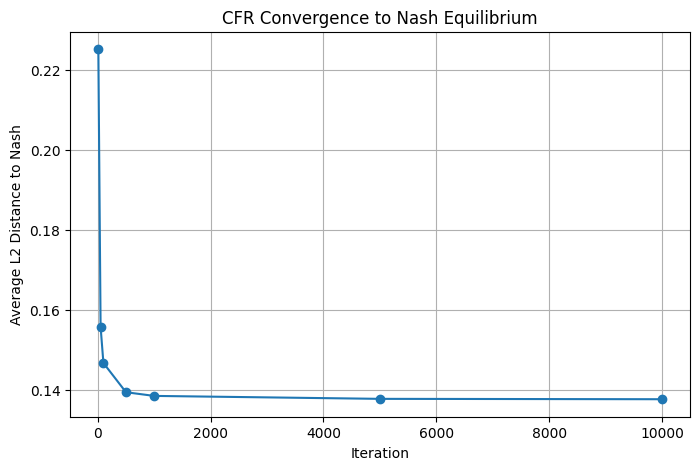

In [38]:
# Train for 10,000 iterations
print("Training CFR for 10,000 iterations...")
trainer = CFRTrainer()

# Track convergence
check_iterations = [10, 50, 100, 500, 1000, 5000, 10000]
distances = []

for i, target in enumerate(check_iterations):
    iters = target if i == 0 else (target - check_iterations[i-1])
    trainer.train(iterations=iters, verbose=False)
    dist = compute_strategy_distance(trainer, NASH_P0)
    distances.append(dist)
    print(f"Iteration {target}: Distance to Nash = {dist:.4f}")

# Plot convergence
plot_convergence(distances, check_iterations)

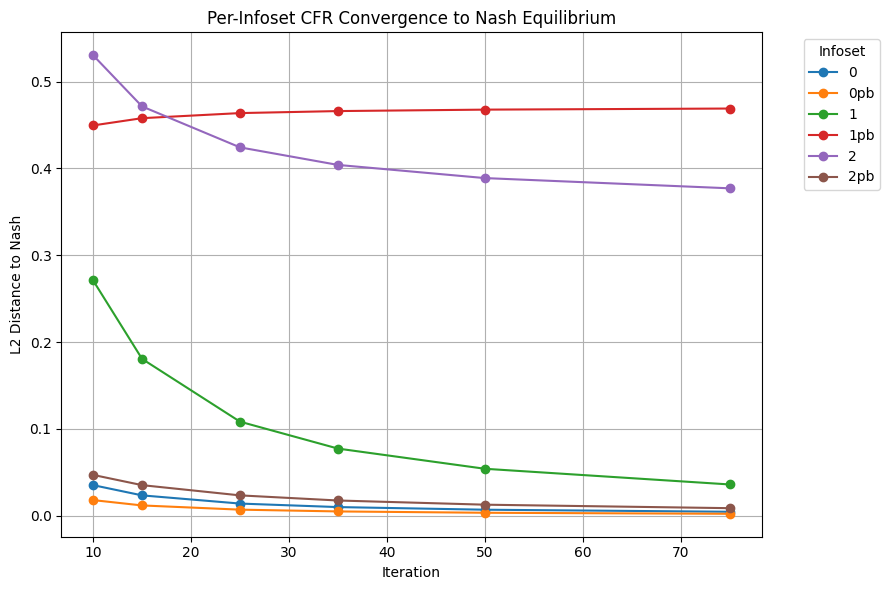

In [39]:
def track_infoset_convergence(trainer: CFRTrainer, nash_dict: Dict, check_iterations: List[int]) -> Dict[str, List[float]]:
    infoset_distances = {infoset: [] for infoset in nash_dict.keys()}

    # Reinitialize a fresh trainer for reproducibility
    trainer.__init__()

    prev_iter = 0
    for target in check_iterations:
        trainer.train(iterations=(target - prev_iter), verbose=False)
        prev_iter = target

        for infoset, nash_strategy in nash_dict.items():
            learned = trainer.get_average_strategy(infoset)
            dist = np.linalg.norm(learned - nash_strategy)
            infoset_distances[infoset].append(dist)

    return infoset_distances

def plot_infoset_convergence(infoset_distances: Dict[str, List[float]], check_iterations: List[int]):
    plt.figure(figsize=(9, 6))
    for infoset, dist_list in infoset_distances.items():
        plt.plot(check_iterations, dist_list, marker='o', label=f"{infoset}")

    plt.xlabel("Iteration")
    plt.ylabel("L2 Distance to Nash")
    plt.title("Per-Infoset CFR Convergence to Nash Equilibrium")
    plt.legend(title="Infoset", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

trainer = CFRTrainer()
check_iterations = [10, 15, 25, 35, 50, 75]

infoset_distances = track_infoset_convergence(trainer, NASH_P0, check_iterations)
plot_infoset_convergence(infoset_distances, check_iterations)


### Display Learned Strategies

In [40]:
print("\n" + "="*60)
print("LEARNED STRATEGIES (Player 0)")
print("="*60)

for infoset in ['0', '1', '2', '0pb', '1pb', '2pb']:
    learned = trainer.get_average_strategy(infoset)
    nash = NASH_P0[infoset]

    print(f"\nInfoset '{infoset}':")
    print(f"  Learned: Pass={learned[0]:.3f}, Bet={learned[1]:.3f}")
    print(f"  Nash:    Pass={nash[0]:.3f}, Bet={nash[1]:.3f}")
    print(f"  Difference: {np.linalg.norm(learned - nash):.4f}")


LEARNED STRATEGIES (Player 0)

Infoset '0':
  Learned: Pass=0.997, Bet=0.003
  Nash:    Pass=1.000, Bet=0.000
  Difference: 0.0047

Infoset '1':
  Learned: Pass=0.974, Bet=0.026
  Nash:    Pass=1.000, Bet=0.000
  Difference: 0.0361

Infoset '2':
  Learned: Pass=0.267, Bet=0.733
  Nash:    Pass=0.000, Bet=1.000
  Difference: 0.3771

Infoset '0pb':
  Learned: Pass=0.998, Bet=0.002
  Nash:    Pass=1.000, Bet=0.000
  Difference: 0.0024

Infoset '1pb':
  Learned: Pass=0.998, Bet=0.002
  Nash:    Pass=0.667, Bet=0.333
  Difference: 0.4690

Infoset '2pb':
  Learned: Pass=0.006, Bet=0.994
  Nash:    Pass=0.000, Bet=1.000
  Difference: 0.0088


0,0pb,2pb converge quickly to nash as they have certain 'best actions'. 
1pb would rather pass than risk losing, whereas 2 deviates from nash making a mixed strategy where passing makes the agent seem like they have a worse hand and could prompt the opponent to bet.

---
## Reflection Questions (5 points for each question, total 15 points)

Answer the following questions based on your implementation and results. Each answer should be 3-5 sentences.

### Question 1: Convergence Analysis
Which information sets converged fastest to Nash equilibrium? Why do you think this happened? Consider the frequency with which different infosets are reached during play.

**Your Answer:**

1 and 2 infosets take the longest to train, this is beacuse player0 develops a strategy. 0, 0pb, and 2pb converge to nash because they have a direct best action. 1 and 2 have more varied results, this is because the agent learns the opponent's actions are influenced by its and develops a strategy to gain while minimizing regret.\
\
0p_p, 1p_p, 2b_, 2p_b seem to be the best strategies for player0 under cfr, I wonder if initializing 2 to pass could strengthen player0's deception and increase gain while still minimizing regret. Or if player1 will start playing extra safe and pass more on 1p.\

### Question 2: Counterfactual Reasoning
Explain in your own words why CFR uses counterfactual values (weighted by opponent reach probability $\pi_{-i}$) rather than expected values (weighted by both players' reach). What would go wrong if we used expected values?

**Your Answer:**

Attempting to use both reach probabilities would mean losing observation of how your opponents action influence the game/rewards. CFR uses opponent reach probability to observe what the opponent's action means for the obstructed gamestate, weighted by how often the opponent visits the state. This means CFR measures how the opponent strategy effects rewards.

### Question 3: Scalability
Kuhn Poker has only 12 information sets (6 per player). Real poker games like Texas Hold'em have ~$10^{14}$ infosets. What modifications would be needed to apply CFR to such large games? Mention at least two techniques discussed in class.

**Your Answer:**

Information abstraction: we should cluster hand types (pair, 3oaK, straight, flush,...) to observe how these organized hands stack up to opponents using a shared pool of cards. We should probably still include high-card value, a pair of Aces are alright where a pair of 3's not so much.

We should also first try solving a simplified version of the game with only 2  betting rounds (display 3, display 5). CFR players likely won't bet while their infoset is only their 2 cards, so starting with 3 cards displayed should jump to a more important learning round. Removing the second to last betting round speeds up information gain for more direct action->effect, but we lose observations of regret that could prove beneficial.

I expect CFR holdem to include a LOT of check/folding

## CFR+

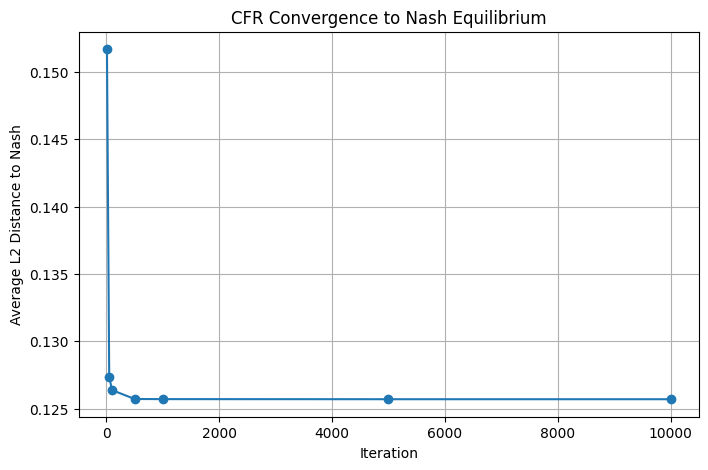

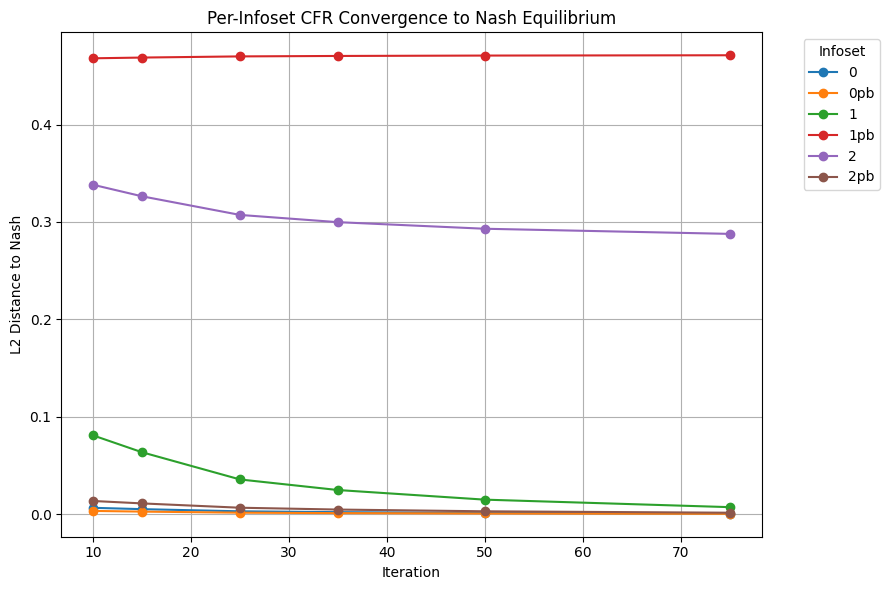


LEARNED STRATEGIES (Player 0)

Infoset '0':
  Learned: Pass=1.000, Bet=0.000
  Nash:    Pass=1.000, Bet=0.000
  Difference: 0.0006

Infoset '1':
  Learned: Pass=0.995, Bet=0.005
  Nash:    Pass=1.000, Bet=0.000
  Difference: 0.0071

Infoset '2':
  Learned: Pass=0.203, Bet=0.797
  Nash:    Pass=0.000, Bet=1.000
  Difference: 0.2877

Infoset '0pb':
  Learned: Pass=1.000, Bet=0.000
  Nash:    Pass=1.000, Bet=0.000
  Difference: 0.0003

Infoset '1pb':
  Learned: Pass=1.000, Bet=0.000
  Nash:    Pass=0.667, Bet=0.333
  Difference: 0.4711

Infoset '2pb':
  Learned: Pass=0.001, Bet=0.999
  Nash:    Pass=0.000, Bet=1.000
  Difference: 0.0014


In [42]:
class CFRPlusTrainer(CFRTrainer):
    """CFR+ variant of Counterfactual Regret Minimization for Kuhn Poker."""

    def __init__(self):
        super().__init__()
        self.iteration_weight = 0  # For weighted averaging in CFR+

    def cfr_recursive(
        self,
        cards: Tuple[int, int],
        history: str,
        reach_0: float,
        reach_1: float,
        updating_player: int
    ) -> float:
        if self.game.is_terminal(history):
            payoff = self.game.get_payoff(history, cards)
            return payoff if updating_player == 0 else -payoff

        current_player = self.game.get_current_player(history)
        infoset = self.game.get_information_set(cards[current_player], history, current_player)
        strategy = self.get_strategy(infoset)
        action_values = np.zeros(2)

        for a in self.game.get_available_actions(history):
            next_history = history + self.game.actions_map[a]
            if current_player == 0:
                next_reach_0, next_reach_1 = reach_0 * strategy[a], reach_1
            else:
                next_reach_0, next_reach_1 = reach_0, reach_1 * strategy[a]

            action_values[a] = self.cfr_recursive(
                cards, next_history, next_reach_0, next_reach_1, updating_player
            )

        value = np.dot(strategy, action_values)

        if current_player == updating_player:
            opponent_reach = reach_1 if current_player == 0 else reach_0
            for a in self.game.get_available_actions(history):
                regret = action_values[a] - value
                # CFR+: clamp cumulative regrets at zero
                self.regret_sum[infoset][a] = np.maximum(
                    0, self.regret_sum[infoset][a] + opponent_reach * regret
                )

            own_reach = reach_0 if current_player == 0 else reach_1
            self.strategy_sum[infoset] += self.iteration_weight * own_reach * strategy

        return value

    def train(self, iterations: int, verbose: bool = True):
        history = {'iterations': [], 'avg_strategy': []}
        cards_deals = [(0, 1), (0, 2), (1, 0), (1, 2), (2, 0), (2, 1)]

        for i in range(iterations):
            self.iteration_weight = i + 1  # CFR+ weighted averaging
            for cards in cards_deals:
                self.cfr_recursive(cards, "", 1.0, 1.0, updating_player=0)
                self.cfr_recursive(cards, "", 1.0, 1.0, updating_player=1)

            if verbose and (i + 1) % 1000 == 0:
                avg_strategy_snapshot = {
                    infoset: self.get_average_strategy(infoset)
                    for infoset in self.strategy_sum.keys()
                }
                history['iterations'].append(i + 1)
                history['avg_strategy'].append(avg_strategy_snapshot)
                print(f"Iteration {i + 1} completed:")
                for infoset, strat in avg_strategy_snapshot.items():
                    print(f"  {infoset}: Pass {strat[0]:.3f}, Bet {strat[1]:.3f}")

        return history

trainer = CFRPlusTrainer()
check_iterations = [10, 50, 100, 500, 1000, 5000, 10000]
distances = []
for target in check_iterations:
    trainer.train(iterations=target - (check_iterations.index(target) and check_iterations[check_iterations.index(target) - 1]), verbose=False)
    dist = compute_strategy_distance(trainer, NASH_P0)
    distances.append(dist)
plot_convergence(distances, check_iterations)

trainer = CFRPlusTrainer()
check_iterations = [10, 15, 25, 35, 50, 75]

infoset_distances = track_infoset_convergence(trainer, NASH_P0, check_iterations)
plot_infoset_convergence(infoset_distances, check_iterations)
print("\n" + "="*60)
print("LEARNED STRATEGIES (Player 0)")
print("="*60)

for infoset in ['0', '1', '2', '0pb', '1pb', '2pb']:
    learned = trainer.get_average_strategy(infoset)
    nash = NASH_P0[infoset]

    print(f"\nInfoset '{infoset}':")
    print(f"  Learned: Pass={learned[0]:.3f}, Bet={learned[1]:.3f}")
    print(f"  Nash:    Pass={nash[0]:.3f}, Bet={nash[1]:.3f}")
    print(f"  Difference: {np.linalg.norm(learned - nash):.4f}")


faster convergence closer to NE. Rarely betting on 1, even more rarely passing on 2pb (which is crazy). Disguising 2 with pass actions is reduced in occurance from vanilla CFR.

---
## Submission Checklist

Before submitting, verify:
- [ ] All `TODO` cells have been completed
- [ ] All code cells run without errors (Kernel → Restart & Run All)
- [ ] Public tests pass
- [ ] Reflection questions are answered
- [ ] Plots are visible in the notebook
- [ ] Your name and student ID are filled in at the top

**Submit:** Upload this `.ipynb` file to the course portal.

---

## Grading Rubric (100 points total)

| Component | Points |
|-----------|--------|
| Task 1: Game Representation | 25 |
| Task 2: CFR Core | 30 |
| Task 3: Training Loop | 25 |
| Task 4: Evaluation & Visualization | 20 |
| Reflection Questions | 0 |
| **Extra Credit:** CFR+ implementation | +10 |

Good luck! 🎲🃏
